# Аналитика закупок и импортозависимости

**Отрасль:** Нефтегазовая вертикально-интегрированная компания  
**Направление:** Стратегический снабжение, закупки, управление импортозависимостью  
**Стек:** Python, Pandas, SQL (SQLite), Matplotlib, Plotly  

---

## Описание проекта

В репозитории реализован полный цикл аналитики закупочной деятельности: от загрузки нормативно-справочной информации (НСИ) до бизнес-выводов для руководства. В основе лежат реальные справочники филиалов, категорий и поставщиков, дополненные синтетическими факт-данными по закупочным процедурам.

> **Важно:** Факт-данные по закупкам (`fact_purchases`, `fact_services.csv`) являются синтетическими.

In [ ]:
# !pip install -r ../requirements.txt


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from IPython.display import Image, display
import warnings

warnings.filterwarnings("ignore")

ROSNIEFT_PRIMARY = ["#003B7E", "#E30016", "#6A9E3F", "#F47920", "#FFC700", "#4A4A4A"]
ROSNIEFT_FULL = [
    "#003B7E",
    "#E30016",
    "#6A9E3F",
    "#F47920",
    "#FFC700",
    "#0057A8",
    "#C41230",
    "#8CC63F",
    "#F8991D",
    "#FFDD00",
    "#4A4A4A",
    "#939598",
]
ROSNIEFT_NEUTRAL = ["#E6E6E6", "#BFBFBF", "#939598", "#6D6E71", "#4A4A4A"]
ROSNIEFT_IMPORT_LOCAL = {"import": "#E30016", "local": "#6A9E3F"}
ROSNIEFT_PLAN_FACT = {"plan": "#003B7E", "fact": "#F47920"}

PALETTE = ROSNIEFT_PRIMARY
sns.set_palette(PALETTE)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["figure.facecolor"] = "white"

print("Библиотеки загружены")


Matplotlib is building the font cache; this may take a moment.


Библиотеки загружены


## 1. Загрузка нормативно-справочной информации (НСИ)

Подключаем все справочники. Каждый справочник отвечает за свой срез данных: кто закупает (филиалы), что закупается (категории), у кого закупается (поставщики) и в рамках какой процедуры (закупочные комиссии).

**Уточнения по модели данных:**
- `fact_purchases` (`data/fact_purchases.csv`) — закупки **МТР (материально-технических ресурсов, товаров)**.
- `fact_services` (`data/fact_services.csv`) — закупки **услуг**.
- `dim_filials` (`data/dim_filials.csv`) — филиалы компании с привязкой к бизнес-блоку.
- `dim_categories` (`data/dim_categories.csv`) — классификатор категорий и услуг.
- `dim_suppliers` (`data/dim_suppliers.csv`) — реестр поставщиков.
- `dim_commissions` (`data/dim_commissions.csv`) — закупочные комиссии и тип процедуры.


In [3]:
DATA_DIR = "../data"

dim_filials = pd.read_csv(f"{DATA_DIR}/dim_filials.csv")
dim_categories = pd.read_csv(f"{DATA_DIR}/dim_categories.csv")
dim_suppliers = pd.read_csv(f"{DATA_DIR}/dim_suppliers.csv")
dim_commissions = pd.read_csv(f"{DATA_DIR}/dim_commissions.csv")

fact_purchases = pd.read_csv(f"{DATA_DIR}/fact_purchases.csv")
fact_services = pd.read_csv(f"{DATA_DIR}/fact_services.csv")

fact_purchases["ДатаЗакупки"] = pd.to_datetime(fact_purchases["ДатаЗакупки"])
fact_purchases["Год"] = fact_purchases["ДатаЗакупки"].dt.year
fact_purchases["Полугодие"] = np.where(
    fact_purchases["ДатаЗакупки"].dt.month <= 6, 1, 2
)

fact_services["ДатаЗакупки"] = pd.to_datetime(fact_services["ДатаЗакупки"])
fact_services["Год"] = fact_services["ДатаЗакупки"].dt.year
fact_services["Полугодие"] = np.where(fact_services["ДатаЗакупки"].dt.month <= 6, 1, 2)

print("Справочники и факты успешно загружены:")
print(f"  Филиалы:            {len(dim_filials):,} записей")
print(f"  Категории:          {len(dim_categories):,} записей")
print(f"  Поставщики:         {len(dim_suppliers):,} записей")
print(f"  Комиссии:           {len(dim_commissions):,} записей")
print(f"  Закупки МТР (факт): {len(fact_purchases):,} записей")
print(f"  Закупки услуг:      {len(fact_services):,} записей")


Справочники и факты успешно загружены:
  Филиалы:            87 записей
  Категории:          196 записей
  Поставщики:         330 записей
  Комиссии:           24 записей
  Закупки МТР (факт): 6,422 записей
  Закупки услуг:      2,168 записей


## 2. Создание аналитического хранилища (SQLite in-memory)

In [4]:
conn = sqlite3.connect(":memory:")

dim_filials.to_sql("dim_filials", conn, index=False, if_exists="replace")
dim_categories.to_sql("dim_categories", conn, index=False, if_exists="replace")
dim_suppliers.to_sql("dim_suppliers", conn, index=False, if_exists="replace")
dim_commissions.to_sql("dim_commissions", conn, index=False, if_exists="replace")
fact_purchases.to_sql("fact_purchases", conn, index=False, if_exists="replace")
fact_services.to_sql("fact_services", conn, index=False, if_exists="replace")

conn.execute("CREATE INDEX idx_fp_filial ON fact_purchases(КодФилиала)")
conn.execute("CREATE INDEX idx_fp_inn ON fact_purchases(ИНН)")
conn.execute("CREATE INDEX idx_fp_mtr ON fact_purchases(КодГруппы)")
conn.commit()

print("SQLite хранилище создано. Индексы по ключам: КодФилиала, ИНН, КодГруппы")


SQLite хранилище создано. Индексы по ключам: КодФилиала, ИНН, КодГруппы


## 3. Обзор хранилища (Warehouse Summary)

In [5]:
warehouse_summary = pd.DataFrame(
    [
        {
            "Таблица": "dim_filials",
            "Тип": "Справочник",
            "Строк": len(dim_filials),
            "Столбцов": dim_filials.shape[1],
            "Столбцы": ", ".join(dim_filials.columns),
        },
        {
            "Таблица": "dim_categories",
            "Тип": "Справочник",
            "Строк": len(dim_categories),
            "Столбцов": dim_categories.shape[1],
            "Столбцы": ", ".join(dim_categories.columns),
        },
        {
            "Таблица": "dim_suppliers",
            "Тип": "Справочник",
            "Строк": len(dim_suppliers),
            "Столбцов": dim_suppliers.shape[1],
            "Столбцы": ", ".join(dim_suppliers.columns),
        },
        {
            "Таблица": "dim_commissions",
            "Тип": "Справочник",
            "Строк": len(dim_commissions),
            "Столбцов": dim_commissions.shape[1],
            "Столбцы": ", ".join(dim_commissions.columns),
        },
        {
            "Таблица": "fact_purchases",
            "Тип": "Таблица фактов",
            "Строк": len(fact_purchases),
            "Столбцов": fact_purchases.shape[1],
            "Столбцы": ", ".join(fact_purchases.columns),
        },
        {
            "Таблица": "fact_services",
            "Тип": "Таблица фактов",
            "Строк": 0 if fact_services is None else len(fact_services),
            "Столбцов": 0 if fact_services is None else fact_services.shape[1],
            "Столбцы": (
                ", ".join(fact_services.columns) if fact_services is not None else ""
            ),
        },
    ]
)

display(warehouse_summary)


,Таблица,Тип,Строк,Столбцов,Столбцы
0,dim_filials,Справочник,87,5,"КодФилиала, НазваниеФилиала, БизнесБлок, Регио..."
1,dim_categories,Справочник,196,3,"КодГруппы, НазваниеГруппы, Категория"
2,dim_suppliers,Справочник,330,8,"ИНН, НазваниеПоставщика, УровеньПоставщика, Ст..."
3,dim_commissions,Справочник,24,5,"КодКомиссии, НазваниеКомиссии, ТипЗакупки, Тип..."
4,fact_purchases,Таблица фактов,6422,14,"КодЗакупки, НазваниеЗакупки, ДатаЗакупки, КодФ..."
5,fact_services,Таблица фактов,2168,13,"КодЗакупки, НазваниеЗакупки, ДатаЗакупки, КодФ..."


In [6]:
# Расчётные витрины для внешних систем


# 1. Динамика расходов по бизнес-блокам и годам
spend_by_block = pd.read_sql(
    """
    SELECT
        p.Год
        ,f.БизнесБлок
        ,ROUND(SUM(p.СуммаФакт) / 1e6, 2) AS Факт_млн
        ,ROUND(SUM(p.СуммаПлан) / 1e6, 2) AS План_млн
        ,COUNT(*) AS ЧислоПроцедур
    FROM fact_purchases p
    JOIN dim_filials f ON f.КодФилиала = p.КодФилиала
    GROUP BY p.Год, f.БизнесБлок
""",
    conn,
)
spend_by_block.to_csv("../data/_processed/spend_by_block_powerbi.csv", index=False)

# 2. План/факт по бизнес-блокам
plan_fact = pd.read_sql(
    """
    SELECT
        f.БизнесБлок
        ,ROUND(SUM(p.СуммаПлан) / 1e6, 2) AS План_млн
        ,ROUND(SUM(p.СуммаФакт) / 1e6, 2) AS Факт_млн
        ,ROUND((SUM(p.СуммаФакт) - SUM(p.СуммаПлан)) / SUM(p.СуммаПлан) * 100, 1) AS Отклонение_pct
    FROM fact_purchases p
    JOIN dim_filials f ON f.КодФилиала = p.КодФилиала
    GROUP BY f.БизнесБлок
""",
    conn,
)
plan_fact.to_csv("../data/_processed/plan_fact_powerbi.csv", index=False)

# 3. Доля импорта по бизнес-блокам
import_share = pd.read_sql(
    """
    SELECT
        f.БизнесБлок
        ,p.СтранаПроисхождения
        ,ROUND(SUM(p.СуммаФакт) / 1e6, 2) AS Факт_млн
        ,ROUND(SUM(p.СуммаФакт) * 1.0 / SUM(SUM(p.СуммаФакт)) OVER (PARTITION BY f.БизнесБлок) * 100, 2) AS Доля_pct
        ,SUM(p.ФлагИмпорта) AS ЧислоИмпортныхПозиций
    FROM fact_purchases p
    JOIN dim_filials f ON f.КодФилиала = p.КодФилиала
    GROUP BY f.БизнесБлок, p.СтранаПроисхождения
""",
    conn,
)
import_share.to_csv("../data/_processed/import_share_powerbi.csv", index=False)

# 4. ABC-анализ групп / категорий
abc_mtr = pd.read_sql(
    """
    SELECT
        c.Категория
        ,c.НазваниеГруппы
        ,ROUND(SUM(p.СуммаФакт) / 1e6, 2) AS Факт_млн
        ,ROUND(SUM(p.СуммаФакт) * 1.0 / SUM(SUM(p.СуммаФакт)) OVER () * 100, 2) AS Доля_pct
    FROM fact_purchases p
    JOIN dim_categories c ON c.КодГруппы = p.КодГруппы
    GROUP BY c.Категория, c.НазваниеГруппы
    ORDER BY Факт_млн DESC
""",
    conn,
)
abc_mtr["НакопленнаяДоля"] = abc_mtr["Доля_pct"].cumsum()
abc_mtr["ABC"] = pd.cut(
    abc_mtr["НакопленнаяДоля"],
    bins=[-1, 80, 95, 100],
    labels=["A", "B", "C"],
)
abc_mtr.to_csv("../data/_processed/abc_mtr_powerbi.csv", index=False)

# 5. Концентрация закупок по поставщикам
supplier_concentration = pd.read_sql(
    """
    SELECT
        s.ИНН
        ,s.НазваниеПоставщика
        ,ROUND(SUM(p.СуммаФакт) / 1e6, 2) AS Факт_млн
        ,COUNT(*) AS ЧислоПроцедур
    FROM fact_purchases p
    JOIN dim_suppliers s ON s.ИНН = p.ИНН
    GROUP BY s.ИНН, s.НазваниеПоставщика
    ORDER BY Факт_млн DESC
""",
    conn,
)
supplier_concentration["ДоляРынка_pct"] = (
    supplier_concentration["Факт_млн"] / supplier_concentration["Факт_млн"].sum() * 100
).round(2)
supplier_concentration["НакопленнаяДоля_pct"] = supplier_concentration[
    "ДоляРынка_pct"
].cumsum()
supplier_concentration.to_csv(
    "../data/_processed/supplier_concentration_powerbi.csv", index=False
)

# 6. Сводка по закупочным комиссиям
commission_summary = pd.read_sql(
    """
    SELECT
        c.КодКомиссии
        ,c.ТипКомиссии
        ,c.ТипЗакупки
        ,COUNT(p.КодЗакупки) AS ЧислоПроцедур
        ,ROUND(SUM(p.СуммаФакт) / 1e9, 3) AS Сумма_млрд
    FROM dim_commissions c
    LEFT JOIN fact_purchases p ON p.КодКомиссии = c.КодКомиссии
    GROUP BY c.КодКомиссии, c.ТипКомиссии, c.ТипЗакупки
    UNION ALL
    SELECT
        c.КодКомиссии
        ,c.ТипКомиссии
        ,c.ТипЗакупки
        ,COUNT(s.КодЗакупки) AS ЧислоПроцедур
        ,ROUND(SUM(s.СуммаФакт) / 1e9, 3) AS Сумма_млрд
    FROM dim_commissions c
    LEFT JOIN fact_services s ON s.КодКомиссии = c.КодКомиссии
    GROUP BY c.КодКомиссии, c.ТипКомиссии, c.ТипЗакупки
""",
    conn,
)
commission_summary.to_csv(
    "../data/_processed/commission_summary_powerbi.csv", index=False
)

print("Расчётные витрины сохранены в ../data/_processed/")


Расчётные витрины сохранены в ../data/_processed/


## Показатель 1. Динамика закупочных расходов по бизнес-блокам

Год,2022,2023,2024,2025
БизнесБлок,,,,
ББ Газ,142.29,87.38,98.30,49.96
ББ Прочие,770.29,688.94,870.58,723.13
ББ НПН,3096.35,553.47,886.30,895.47
ББ КИЛ,942.89,1863.32,1226.00,1076.73
ББ РиД,3410.06,1961.94,1963.63,2877.84
ББ Сервис,542.15,938.44,507.47,3208.29


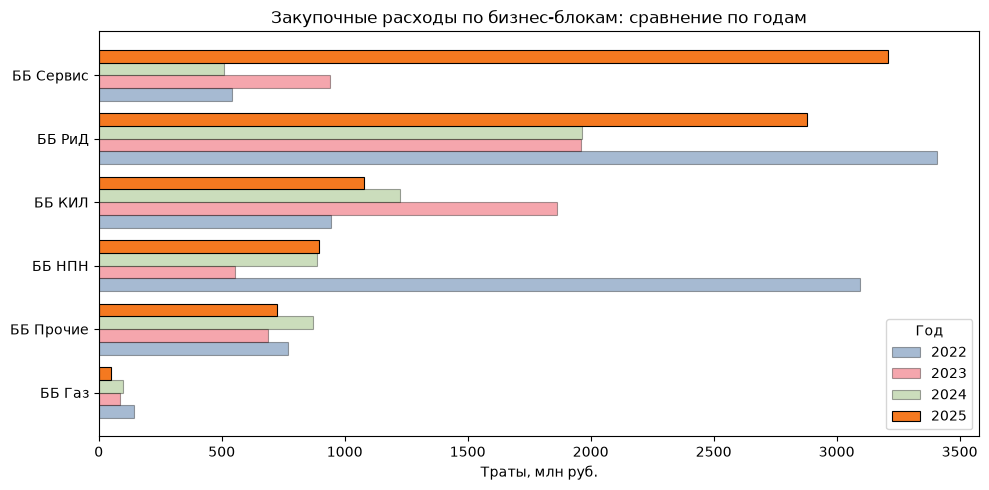

In [7]:
query = """
SELECT 
    p.Год
    ,f.БизнесБлок
    ,ROUND(SUM(p.СуммаФакт) / 1e6, 2) AS Траты_млн
    ,COUNT(*) AS ЧислоПроцедур
FROM fact_purchases p
JOIN dim_filials f ON f.КодФилиала = p.КодФилиала
GROUP BY p.Год, f.БизнесБлок
ORDER BY f.БизнесБлок, p.Год
"""

spend_by_block_year = pd.read_sql(query, conn)

spend_pivot = spend_by_block_year.pivot(
    index="БизнесБлок", columns="Год", values="Траты_млн"
)
spend_pivot = spend_pivot.sort_values(by=spend_pivot.columns[-1], ascending=True)
display(spend_pivot)

years = list(spend_pivot.columns)
y_pos = np.arange(len(spend_pivot))
bar_h = 0.8 / len(years)

plt.figure(figsize=(10, 5))
for i, yr in enumerate(years):
    offset = (i - (len(years) - 1) / 2) * bar_h
    is_last = yr == years[-1]
    plt.barh(
        y_pos + offset,
        spend_pivot[yr],
        height=bar_h,
        color=PALETTE[i % len(PALETTE)],
        alpha=1.0 if is_last else 0.35,
        edgecolor="black",
        linewidth=0.8,
        label=f"{yr}",
    )
plt.yticks(y_pos, spend_pivot.index)
plt.xlabel("Траты, млн руб.")
plt.title("Закупочные расходы по бизнес-блокам: сравнение по годам", fontsize=12)
plt.legend(title="Год")
plt.tight_layout()
plt.savefig("../images/Figure_1.png", dpi=150, bbox_inches="tight")
plt.show()


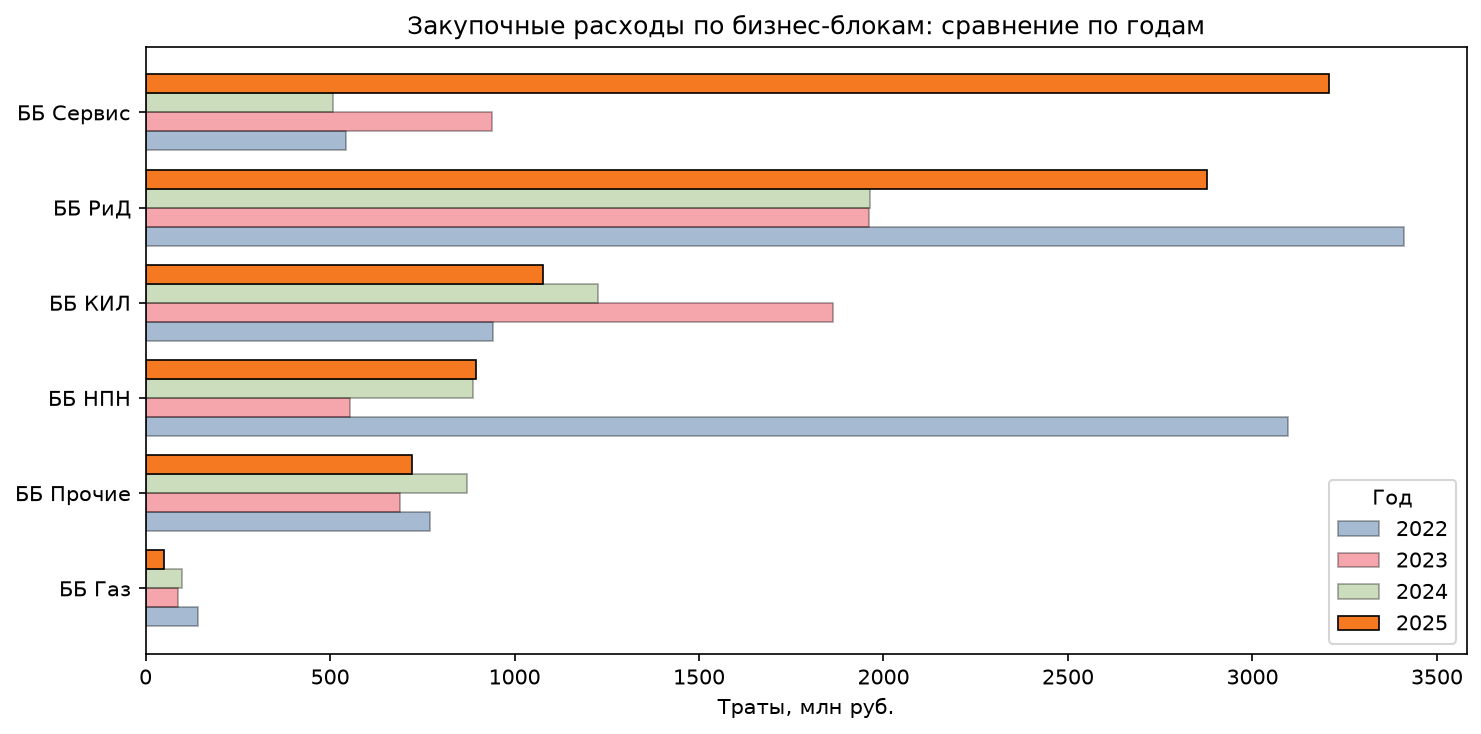

In [8]:
display(Image(filename="../images/Figure_1.png"))


## Показатель 2. План / факт анализ

,БизнесБлок,План_млн,Факт_млн,Отклонение_pct
0,ББ КИЛ,5433.46,5108.94,-6.0
1,ББ Газ,400.81,377.92,-5.7
2,ББ Прочие,3108.59,3052.95,-1.8
3,ББ РиД,10364.25,10213.48,-1.5
4,ББ НПН,5482.63,5431.58,-0.9
5,ББ Сервис,5232.68,5196.34,-0.7


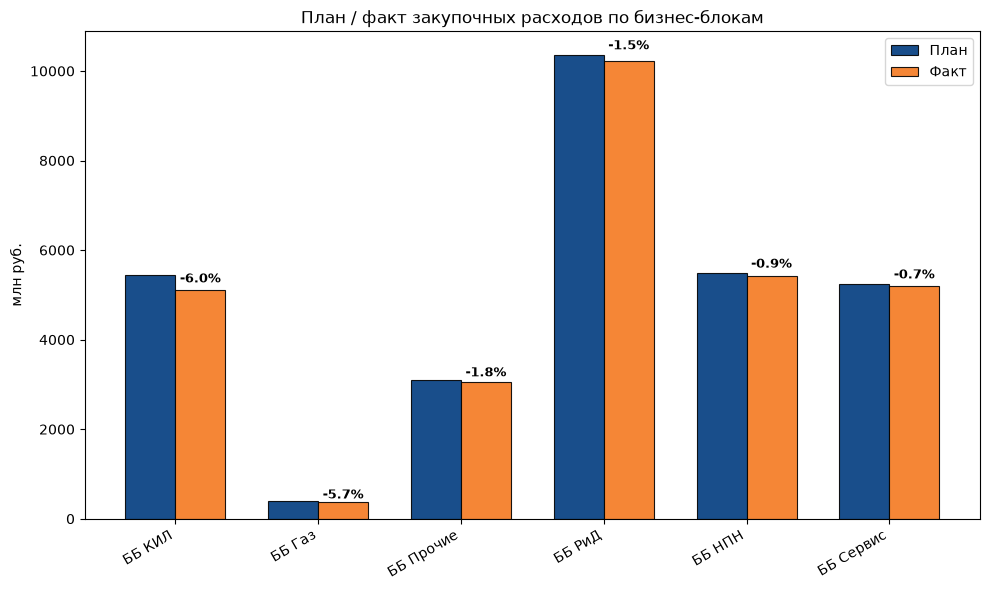

In [14]:
query = """
SELECT 
    f.БизнесБлок
    ,ROUND(SUM(p.СуммаПлан) / 1e6, 2) AS План_млн
    ,ROUND(SUM(p.СуммаФакт) / 1e6, 2) AS Факт_млн
    ,ROUND(
        100.0 * (SUM(p.СуммаФакт) - SUM(p.СуммаПлан)) / SUM(p.СуммаПлан),  1
    ) AS Отклонение_pct
FROM fact_purchases p
JOIN dim_filials f ON f.КодФилиала = p.КодФилиала
GROUP BY f.БизнесБлок
ORDER BY ABS(Отклонение_pct) DESC
"""

plan_fact_by_block = pd.read_sql(query, conn)
display(plan_fact_by_block)

x = np.arange(len(plan_fact_by_block))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(
    x - width / 2,
    plan_fact_by_block["План_млн"],
    width,
    label="План",
    color=ROSNIEFT_PLAN_FACT["plan"],
    alpha=0.9,
    edgecolor="black",
    linewidth=0.8,
)
plt.bar(
    x + width / 2,
    plan_fact_by_block["Факт_млн"],
    width,
    label="Факт",
    color=ROSNIEFT_PLAN_FACT["fact"],
    alpha=0.9,
    edgecolor="black",
    linewidth=0.8,
)

for i, row in plan_fact_by_block.iterrows():
    plt.text(
        i + width / 2,
        row["Факт_млн"] * 1.02,
        f"{row['Отклонение_pct']:+.1f}%",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color="black",
    )

plt.xticks(x, plan_fact_by_block["БизнесБлок"], rotation=30, ha="right")
plt.title("План / факт закупочных расходов по бизнес-блокам", fontsize=12)
plt.ylabel("млн руб.")
plt.legend()
plt.tight_layout()
plt.savefig("../images/Figure_2.png", dpi=150, bbox_inches="tight")
plt.show()


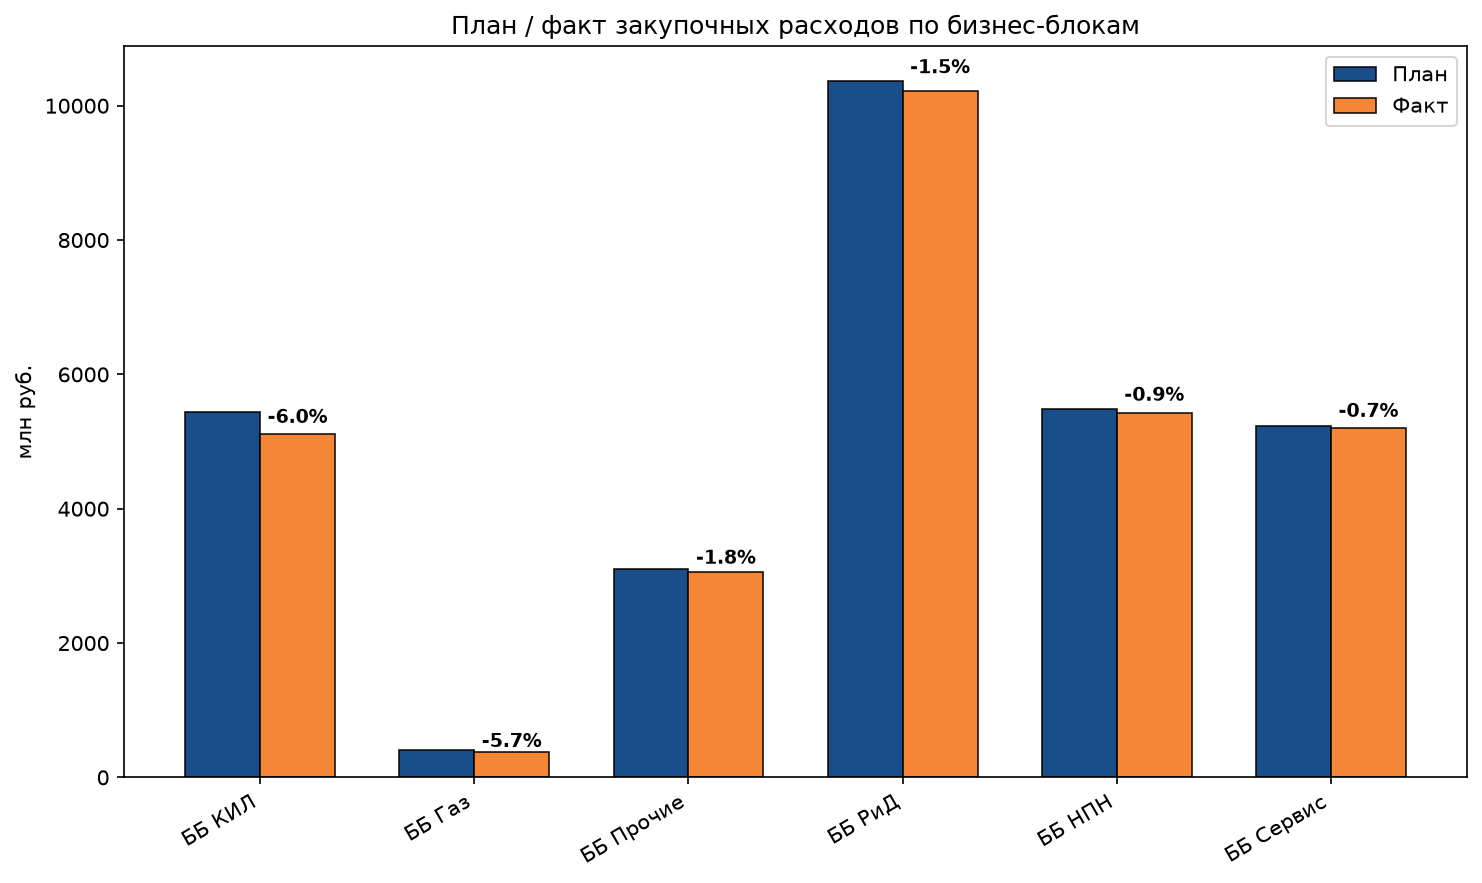

In [12]:
display(Image(filename="../images/Figure_2.png"))


## Показатель 3. Доля импорта по бизнес-блокам

,БизнесБлок,Всего_млн,Импорт_млн,ДоляИмпорта_pct,Локальные_млн
0,ББ Газ,377.92,51.17,13.5,326.75
1,ББ КИЛ,5108.94,383.67,7.5,4725.27
2,ББ Прочие,3052.95,222.02,7.3,2830.93
3,ББ РиД,10213.48,706.54,6.9,9506.94
4,ББ НПН,5431.58,255.95,4.7,5175.63
5,ББ Сервис,5196.34,209.97,4.0,4986.37


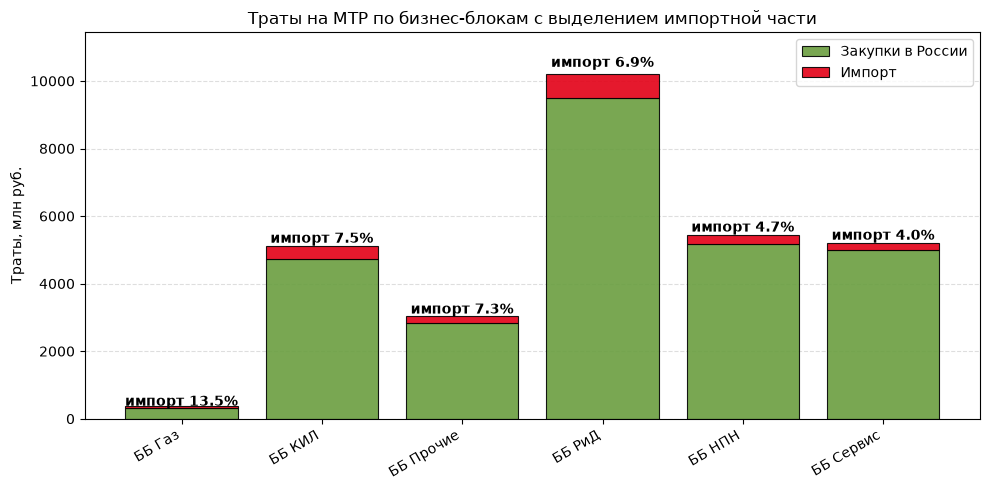

In [17]:
query = """
SELECT 
    f.БизнесБлок
    ,ROUND(SUM(p.СуммаФакт) / 1e6, 2) AS Всего_млн
    ,ROUND(SUM(CASE WHEN p.ФлагИмпорта = 1 THEN p.СуммаФакт ELSE 0 END) / 1e6, 2) AS Импорт_млн
    ,ROUND(
        100.0 * SUM(CASE WHEN p.ФлагИмпорта = 1 THEN p.СуммаФакт ELSE 0 END) / SUM(p.СуммаФакт), 1
    ) AS ДоляИмпорта_pct
FROM fact_purchases p
JOIN dim_filials f ON f.КодФилиала = p.КодФилиала
GROUP BY f.БизнесБлок
ORDER BY ДоляИмпорта_pct DESC
"""

import_by_block = pd.read_sql(query, conn)
import_by_block["Локальные_млн"] = (
    import_by_block["Всего_млн"] - import_by_block["Импорт_млн"]
)
display(import_by_block)


fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    import_by_block["БизнесБлок"],
    import_by_block["Локальные_млн"],
    color=ROSNIEFT_IMPORT_LOCAL["local"],
    alpha=0.9,
    edgecolor="black",
    linewidth=0.8,
    label="Закупки в России",
)
ax.bar(
    import_by_block["БизнесБлок"],
    import_by_block["Импорт_млн"],
    bottom=import_by_block["Локальные_млн"],
    color=ROSNIEFT_IMPORT_LOCAL["import"],
    alpha=0.9,
    edgecolor="black",
    linewidth=0.8,
    label="Импорт",
)

for i, row in import_by_block.iterrows():
    ax.text(
        i,
        row["Всего_млн"] * 1.02,
        f"импорт {row['ДоляИмпорта_pct']:.1f}%",
        ha="center",
        fontsize=10,
        fontweight="bold",
        color="black",
    )

ax.set_ylabel("Траты, млн руб.", color="black")
ax.set_ylim(0, import_by_block["Всего_млн"].max() * 1.12)
ax.tick_params(axis="x", rotation=30, colors="black")
ax.tick_params(axis="y", colors="black")
plt.setp(ax.get_xticklabels(), ha="right")

ax.yaxis.grid(True, linestyle="--", alpha=0.5, color="#BFBFBF")
ax.set_axisbelow(True)

plt.title(
    "Траты на МТР по бизнес-блокам с выделением импортной части",
    fontsize=12,
    color="black",
)
plt.legend()
fig.tight_layout()
plt.savefig("../images/Figure_3.png", dpi=150, bbox_inches="tight")
plt.show()


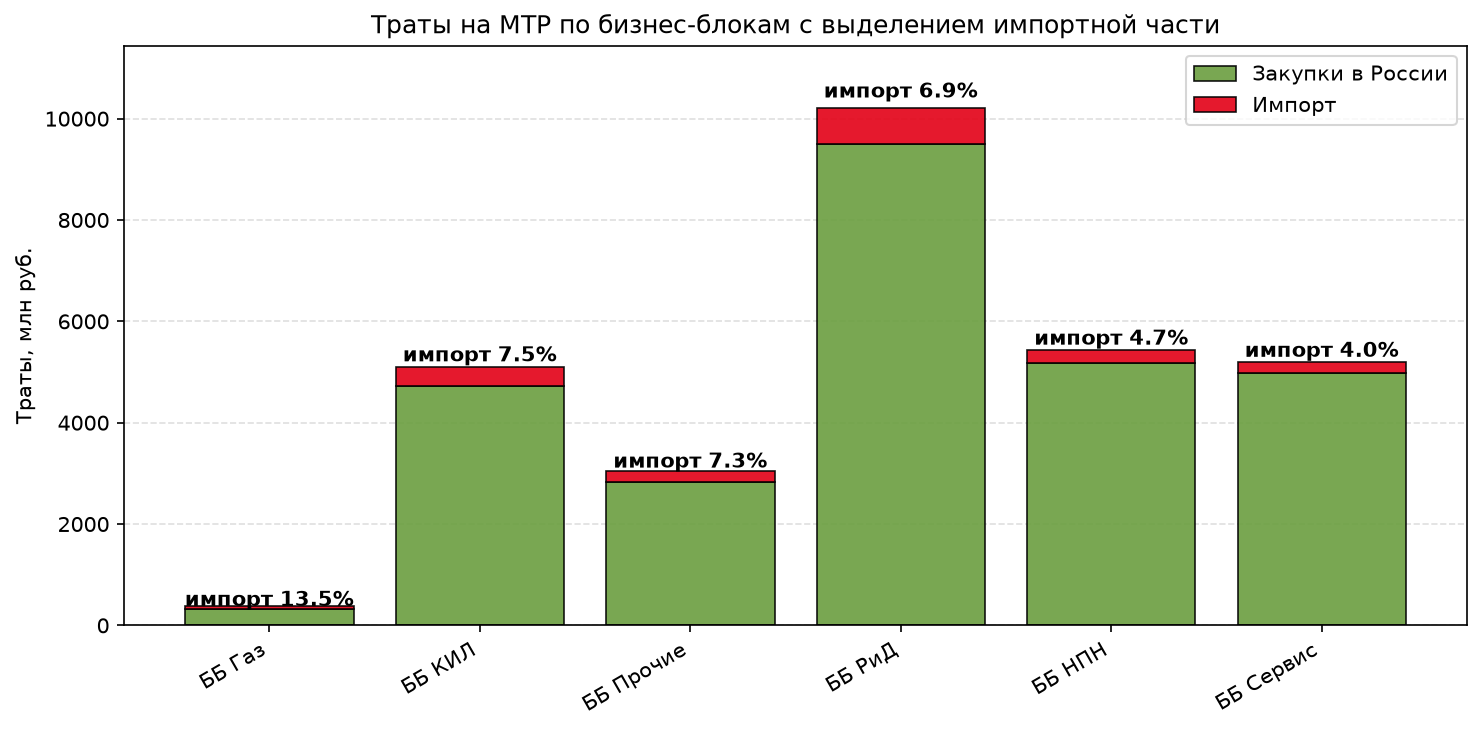

In [18]:
display(Image(filename="../images/Figure_3.png"))


## Показатель 4. РФ vs нерезиденты: выявление «серых» импортных цепочек

In [19]:
# Блок 4a: импортный товар через российских поставщиков (серые схемы)
# Блок 4b: прямой импорт (иностранный поставщик + импортный товар)
# Блок 4c: локализация (иностранный бенефициар, но российское происхождение)

query_gray = """
SELECT 
    'Импорт через РФ поставщика' AS ТипЦепочки
    ,COUNT(*) AS ЧислоПроцедур
    ,ROUND(SUM(p.СуммаФакт) / 1e6, 2) AS Сумма_млн
    ,ROUND(AVG(p.СуммаФакт) / 1e3, 1) AS СредняяСумма_тыс
FROM fact_purchases p
JOIN dim_suppliers s ON s.ИНН = p.ИНН
WHERE p.ФлагИмпорта = 1
  AND s.СтранаРегистрации = 'Россия'

UNION ALL

SELECT 
    'Прямой импорт' AS ТипЦепочки
    ,COUNT(*) AS ЧислоПроцедур
    ,ROUND(SUM(p.СуммаФакт) / 1e6, 2) AS Сумма_млн
    ,ROUND(AVG(p.СуммаФакт) / 1e3, 1) AS СредняяСумма_тыс
FROM fact_purchases p
JOIN dim_suppliers s ON s.ИНН = p.ИНН
WHERE p.ФлагИмпорта = 1
  AND s.СтранаРегистрации != 'Россия'

UNION ALL

SELECT 
    'Локализация (иност.бенефициар, РФ товар)' AS ТипЦепочки
    ,COUNT(*) AS ЧислоПроцедур
    ,ROUND(SUM(p.СуммаФакт) / 1e6, 2) AS Сумма_млн
    ,ROUND(AVG(p.СуммаФакт) / 1e3, 1) AS СредняяСумма_тыс
FROM fact_purchases p
JOIN dim_suppliers s ON s.ИНН = p.ИНН
WHERE p.ФлагИмпорта = 0
  AND s.СтранаБенефициаров != 'Россия'
"""

gray_chains = pd.read_sql(query_gray, conn)
display(gray_chains)

# Детализация: топ стран происхождения в «серых» схемах
query_gray_detail = """
SELECT 
    p.СтранаПроисхождения
    ,COUNT(*) AS ЧислоПроцедур
    ,ROUND(SUM(p.СуммаФакт) / 1e6, 2) AS Сумма_млн
FROM fact_purchases p
JOIN dim_suppliers s ON s.ИНН = p.ИНН
WHERE p.ФлагИмпорта = 1
  AND s.СтранаРегистрации = 'Россия'
GROUP BY p.СтранаПроисхождения
ORDER BY Сумма_млн DESC
"""

gray_chains_detail = pd.read_sql(query_gray_detail, conn)
print("Топ стран происхождения в 'серых' цепочках (РФ поставщик + импорт), млн руб.:")
display(gray_chains_detail)

# Топ категорий в сценарии локализации (иност. бенефициар, российский товар)
query_localization = """
SELECT 
    m.Категория
    ,m.НазваниеГруппы
    ,COUNT(*) AS ЧислоПроцедур
    ,ROUND(SUM(p.СуммаФакт) / 1e6, 2) AS Сумма_млн
FROM fact_purchases p
JOIN dim_suppliers s ON s.ИНН = p.ИНН
JOIN dim_categories m ON m.КодГруппы = p.КодГруппы
WHERE p.ФлагИмпорта = 0
  AND s.СтранаБенефициаров != 'Россия'
GROUP BY m.Категория, m.НазваниеГруппы
ORDER BY Сумма_млн DESC
LIMIT 10
"""

localization_top = pd.read_sql(query_localization, conn)
print(
    "Топ-10 категорий в сценарии 'Локализация (иност. бенефициар, РФ товар)', млн руб.:"
)
display(localization_top)


,ТипЦепочки,ЧислоПроцедур,Сумма_млн,СредняяСумма_тыс
0,Импорт через РФ поставщика,2061,1742.58,845.5
1,Прямой импорт,614,88.87,144.7
2,"Локализация (иност.бенефициар, РФ товар)",1538,5952.59,3870.3


Топ стран происхождения в 'серых' цепочках (РФ поставщик + импорт), млн руб.:


,СтранаПроисхождения,ЧислоПроцедур,Сумма_млн
0,Китай,562,466.59
1,Германия,431,335.37
2,США,325,277.45
3,Турция,175,161.29
4,Белоруссия,184,152.87
5,Казахстан,160,141.10
6,Нидерланды,97,89.68
7,Италия,79,74.47
8,Япония,48,43.76


Топ-10 категорий в сценарии 'Локализация (иност. бенефициар, РФ товар)', млн руб.:


,Категория,НазваниеГруппы,ЧислоПроцедур,Сумма_млн
0,СИЗ и спецодежда,Рабочая обувь,11,2511.39
1,Химические материалы и реагенты,Проппант,11,942.39
2,Химические материалы и реагенты,Кварцевый песок,8,747.35
3,Металлопрокат и трубы,Сварные трубы,10,155.89
4,Металлопрокат и трубы,Сварные трубы большого диаметра,9,115.04
5,Металлопрокат и трубы,Бурильные трубы,9,78.29
6,Топливо и масла,Керосин и авиатопливо,12,67.25
7,Химические материалы и реагенты,Химреагенты (промышленные),14,64.13
8,Металлопрокат и трубы,Чугунные трубы,9,63.93
9,Металлопрокат и трубы,Насосно-компрессорные трубы (НКТ),11,62.49


## Показатель 5. Динамика импортозависимости по полугодиям

,Период,Всего_млн,Импорт_млн,ДоляИмпорта_pct
0,2022-H1,4072.83,232.00,5.7
1,2022-H2,4831.21,208.03,4.3
2,2023-H1,3310.92,230.51,7.0
3,2023-H2,2782.57,238.56,8.6
4,2024-H1,3162.83,253.05,8.0
5,2024-H2,2389.45,220.56,9.2
6,2025-H1,5579.07,232.50,4.2
7,2025-H2,3252.35,214.09,6.6


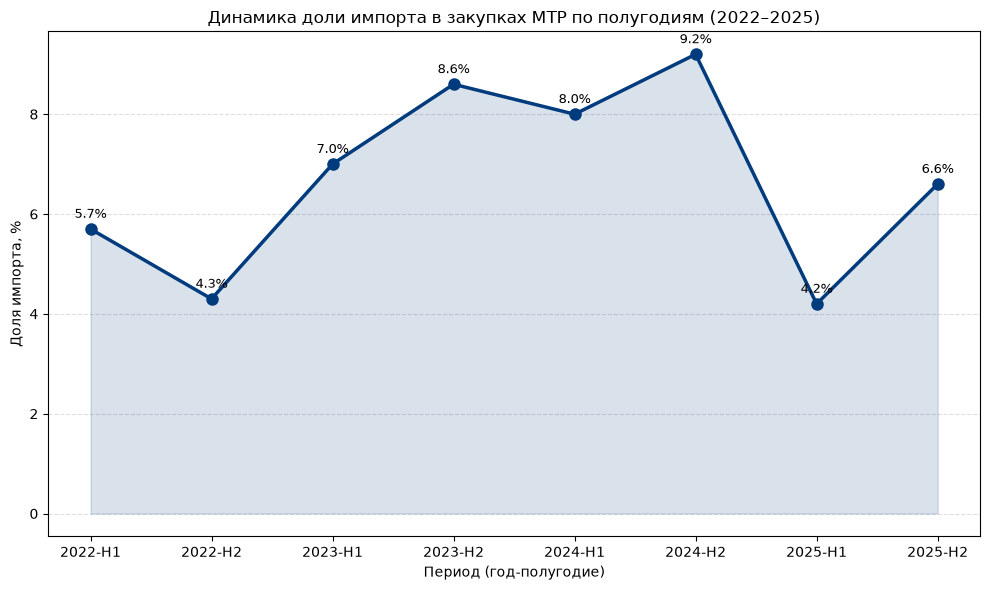

In [21]:
query = """
SELECT 
    p.Год
    ,p.Полугодие
    ,ROUND(SUM(p.СуммаФакт) / 1e6, 2) AS Всего_млн
    ,ROUND(SUM(CASE WHEN p.ФлагИмпорта = 1 THEN p.СуммаФакт ELSE 0 END) / 1e6, 2) AS Импорт_млн
    ,ROUND(
        100.0 * SUM(CASE WHEN p.ФлагИмпорта = 1 THEN p.СуммаФакт ELSE 0 END) / SUM(p.СуммаФакт), 1
    ) AS ДоляИмпорта_pct
FROM fact_purchases p
GROUP BY p.Год, p.Полугодие
ORDER BY p.Год, p.Полугодие
"""

import_trend_halfyear = pd.read_sql(query, conn)
import_trend_halfyear["Период"] = (
    import_trend_halfyear["Год"].astype(str)
    + "-H"
    + import_trend_halfyear["Полугодие"].astype(str)
)
display(import_trend_halfyear[["Период", "Всего_млн", "Импорт_млн", "ДоляИмпорта_pct"]])

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    import_trend_halfyear["Период"],
    import_trend_halfyear["ДоляИмпорта_pct"],
    marker="o",
    linewidth=2.5,
    color=PALETTE[0],
    markersize=8,
)
ax.fill_between(
    import_trend_halfyear["Период"],
    import_trend_halfyear["ДоляИмпорта_pct"],
    alpha=0.15,
    color=PALETTE[0],
)
for x, yv in zip(
    import_trend_halfyear["Период"], import_trend_halfyear["ДоляИмпорта_pct"]
):
    ax.annotate(
        f"{yv:.1f}%",
        (x, yv),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=9,
    )
ax.set_title(
    "Динамика доли импорта в закупках МТР по полугодиям (2022–2025)", fontsize=12
)
ax.set_ylabel("Доля импорта, %")
ax.set_xlabel("Период (год-полугодие)")
ax.yaxis.grid(True, linestyle="--", alpha=0.5, color="#BFBFBF")
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("../images/Figure_4.png", dpi=150, bbox_inches="tight")
plt.show()


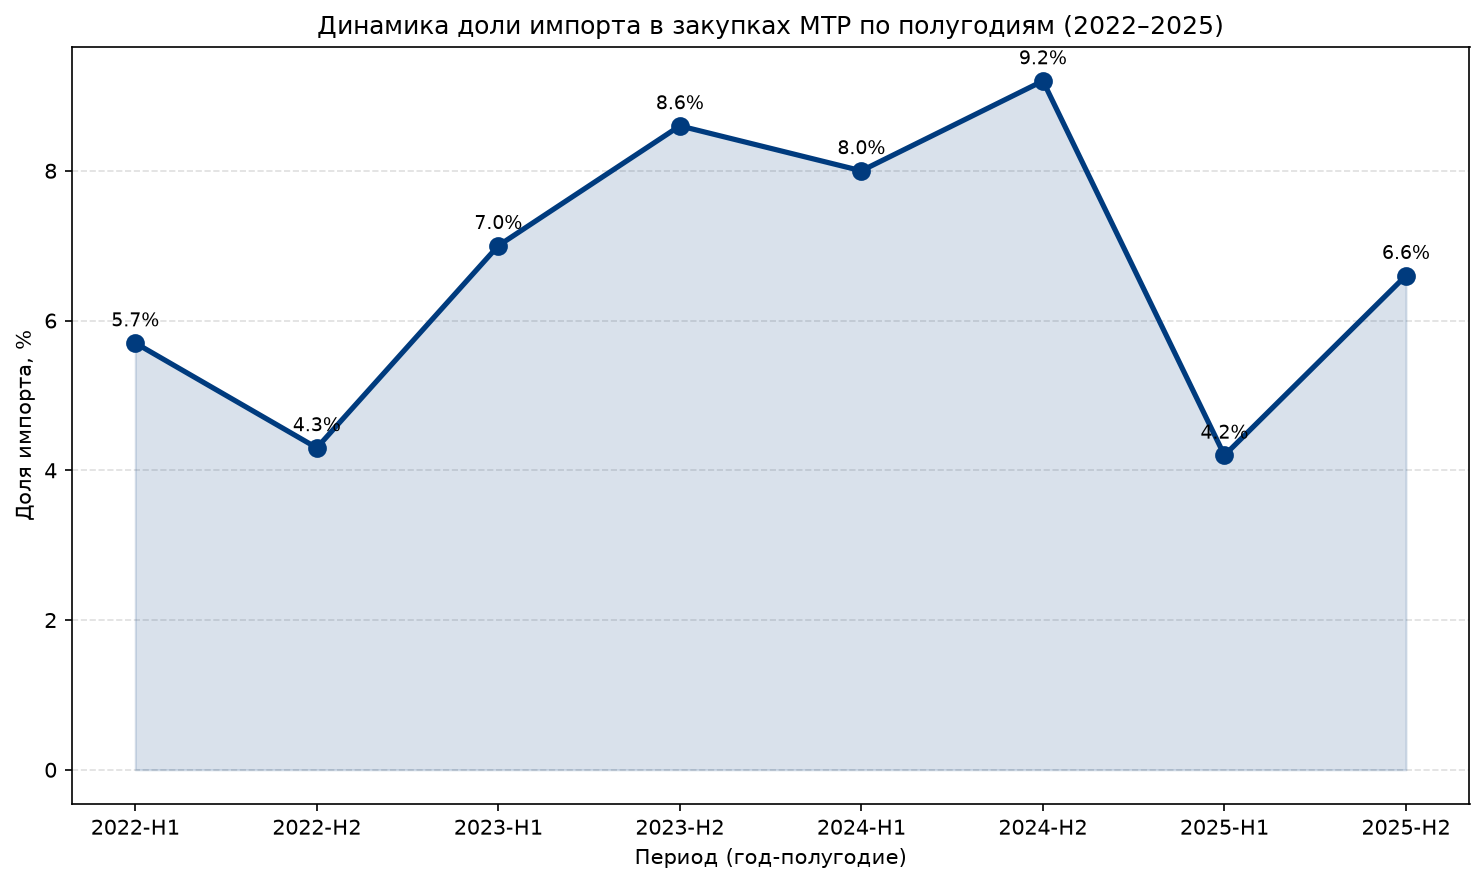

In [22]:
display(Image(filename="../images/Figure_4.png"))


,Период,Всего_млн,Импорт_млн,ДоляИмпорта_pct
0,2022-H1,457.73,9.40,2.1
1,2022-H2,532.51,15.17,2.8
2,2023-H1,361.33,6.76,1.9
3,2023-H2,292.24,11.71,4.0
4,2024-H1,576.28,13.00,2.3
5,2024-H2,643.45,10.68,1.7
6,2025-H1,465.09,10.90,2.3
7,2025-H2,310.14,13.21,4.3


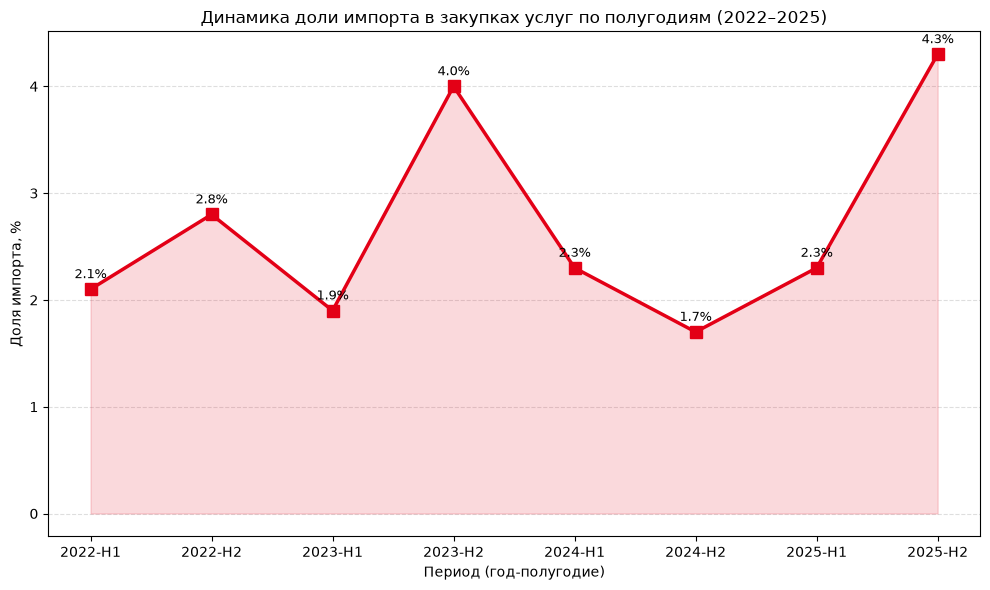

In [24]:
query_svc = """
SELECT 
    p.Год
    ,p.Полугодие
    ,ROUND(SUM(p.СуммаФакт) / 1e6, 2) AS Всего_млн
    ,ROUND(SUM(CASE WHEN p.ФлагИмпорта = 1 THEN p.СуммаФакт ELSE 0 END) / 1e6, 2) AS Импорт_млн
    ,ROUND(
        100.0 * SUM(CASE WHEN p.ФлагИмпорта = 1 THEN p.СуммаФакт ELSE 0 END) / SUM(p.СуммаФакт)
        , 1
    ) AS ДоляИмпорта_pct
FROM fact_services p
GROUP BY p.Год, p.Полугодие
ORDER BY p.Год, p.Полугодие
"""

import_svc_trend = pd.read_sql(query_svc, conn)
import_svc_trend["Период"] = (
    import_svc_trend["Год"].astype(str)
    + "-H"
    + import_svc_trend["Полугодие"].astype(str)
)
display(import_svc_trend[["Период", "Всего_млн", "Импорт_млн", "ДоляИмпорта_pct"]])

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    import_svc_trend["Период"],
    import_svc_trend["ДоляИмпорта_pct"],
    marker="s",
    linewidth=2.5,
    color=PALETTE[1],
    markersize=8,
)
ax.fill_between(
    import_svc_trend["Период"],
    import_svc_trend["ДоляИмпорта_pct"],
    alpha=0.15,
    color=PALETTE[1],
)
for x, yv in zip(import_svc_trend["Период"], import_svc_trend["ДоляИмпорта_pct"]):
    ax.annotate(
        f"{yv:.1f}%",
        (x, yv),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=9,
    )
ax.set_title(
    "Динамика доли импорта в закупках услуг по полугодиям (2022–2025)", fontsize=12
)
ax.set_ylabel("Доля импорта, %")
ax.set_xlabel("Период (год-полугодие)")
ax.yaxis.grid(True, linestyle="--", alpha=0.5, color="#BFBFBF")
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("../images/Figure_5.png", dpi=150, bbox_inches="tight")
plt.show()


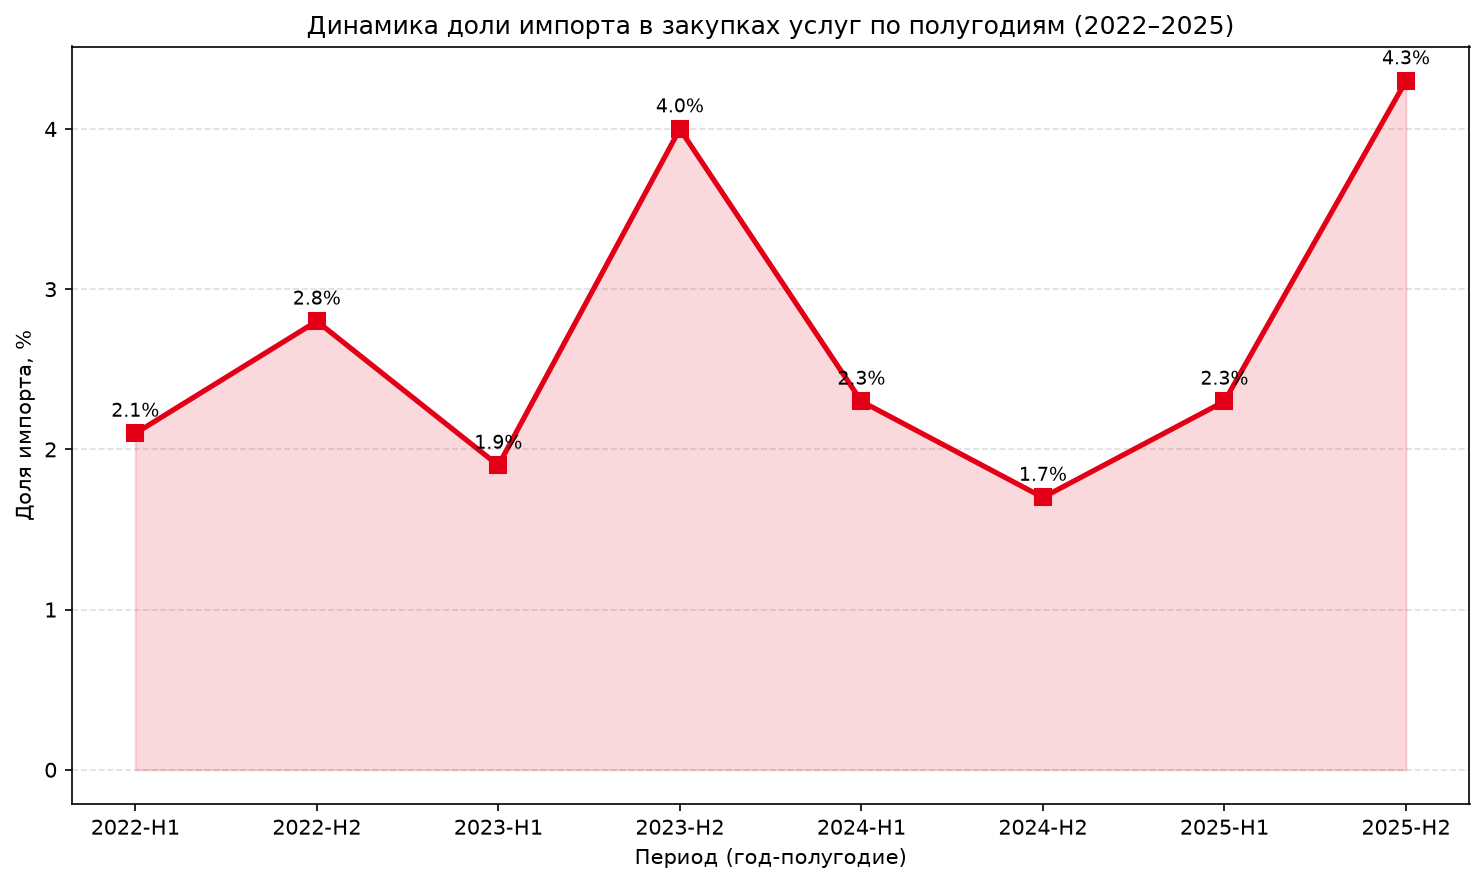

In [25]:
display(Image(filename="../images/Figure_5.png"))


## Показатель 6. ABC-анализ категорий

Распределение категорий по ABC-классам (всего групп: 154):
  A — ключевые группы, в сумме дают до 80% всех трат (основной фокус управления)
  B — группы среднего приоритета, доводят накопленную долю до 95%
  C — прочие группы, оставшиеся ~5% трат



,Число_групп,Траты_млн,Доля_трат_pct
ABC_Класс,,,
A,61,23426.8,79.7
B,59,4478.5,15.2
C,34,1476.0,5.0


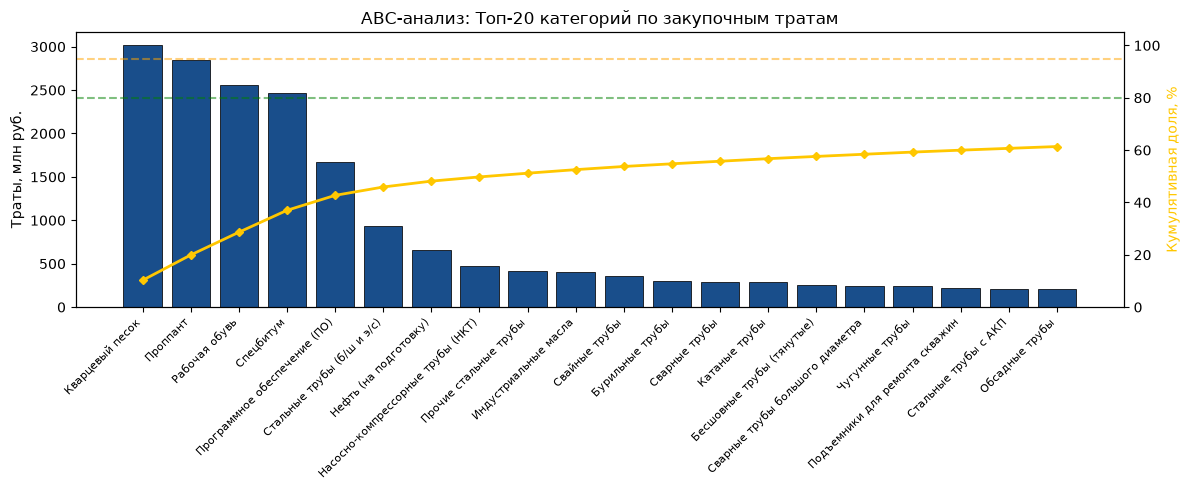

In [32]:
query = """
SELECT 
    m.НазваниеГруппы
    ,m.Категория
    ,ROUND(SUM(p.СуммаФакт) / 1e6, 2) AS Траты_млн
FROM fact_purchases p
JOIN dim_categories m ON m.КодГруппы = p.КодГруппы
GROUP BY m.НазваниеГруппы, m.Категория
ORDER BY Траты_млн DESC
"""

abc_mtr_groups = pd.read_sql(query, conn)

# Расчет кумулятивной доли
abc_mtr_groups["Доля"] = (
    100.0 * abc_mtr_groups["Траты_млн"] / abc_mtr_groups["Траты_млн"].sum()
)
abc_mtr_groups["КумулятивнаяДоля"] = abc_mtr_groups["Доля"].cumsum()

abc_mtr_groups["ABC_Класс"] = abc_mtr_groups["КумулятивнаяДоля"].apply(
    lambda x: "A" if x <= 80 else ("B" if x <= 95 else "C")
)

print(
    "Распределение категорий по ABC-классам (всего групп: {}):".format(
        len(abc_mtr_groups)
    )
)
print(
    "  A — ключевые группы, в сумме дают до 80% всех трат (основной фокус управления)"
)
print("  B — группы среднего приоритета, доводят накопленную долю до 95%")
print("  C — прочие группы, оставшиеся ~5% трат")
print()
class_stats = abc_mtr_groups.groupby("ABC_Класс").agg(
    Число_групп=("НазваниеГруппы", "count"), Траты_млн=("Траты_млн", "sum")
)
class_stats["Доля_трат_pct"] = (
    100 * class_stats["Траты_млн"] / class_stats["Траты_млн"].sum()
).round(1)
class_stats["Траты_млн"] = class_stats["Траты_млн"].round(1)
display(class_stats)

fig, ax1 = plt.subplots(figsize=(12, 5))

top20 = abc_mtr_groups.head(20)
x = np.arange(len(top20))

bars = ax1.bar(
    x,
    top20["Траты_млн"],
    color=[
        PALETTE[0] if c == "A" else (PALETTE[1] if c == "B" else PALETTE[3])
        for c in top20["ABC_Класс"]
    ],
    alpha=0.9,
    edgecolor="black",
    linewidth=0.6,
)
ax1.set_ylabel("Траты, млн руб.", color="black")
ax1.set_xticks(x)
ax1.set_xticklabels(top20["НазваниеГруппы"], rotation=45, ha="right", fontsize=8)

ax2 = ax1.twinx()
ax2.plot(
    x,
    top20["КумулятивнаяДоля"],
    color=PALETTE[4],
    marker="D",
    linewidth=2,
    markersize=4,
)
ax2.axhline(80, color="green", linestyle="--", alpha=0.5, label="80%")
ax2.axhline(95, color="orange", linestyle="--", alpha=0.5, label="95%")
ax2.set_ylabel("Кумулятивная доля, %", color=PALETTE[4])
ax2.set_ylim(0, 105)

plt.title("ABC-анализ: Топ-20 категорий по закупочным тратам", fontsize=12)
fig.tight_layout()
plt.savefig("../images/Figure_6.png", dpi=150, bbox_inches="tight")
plt.show()


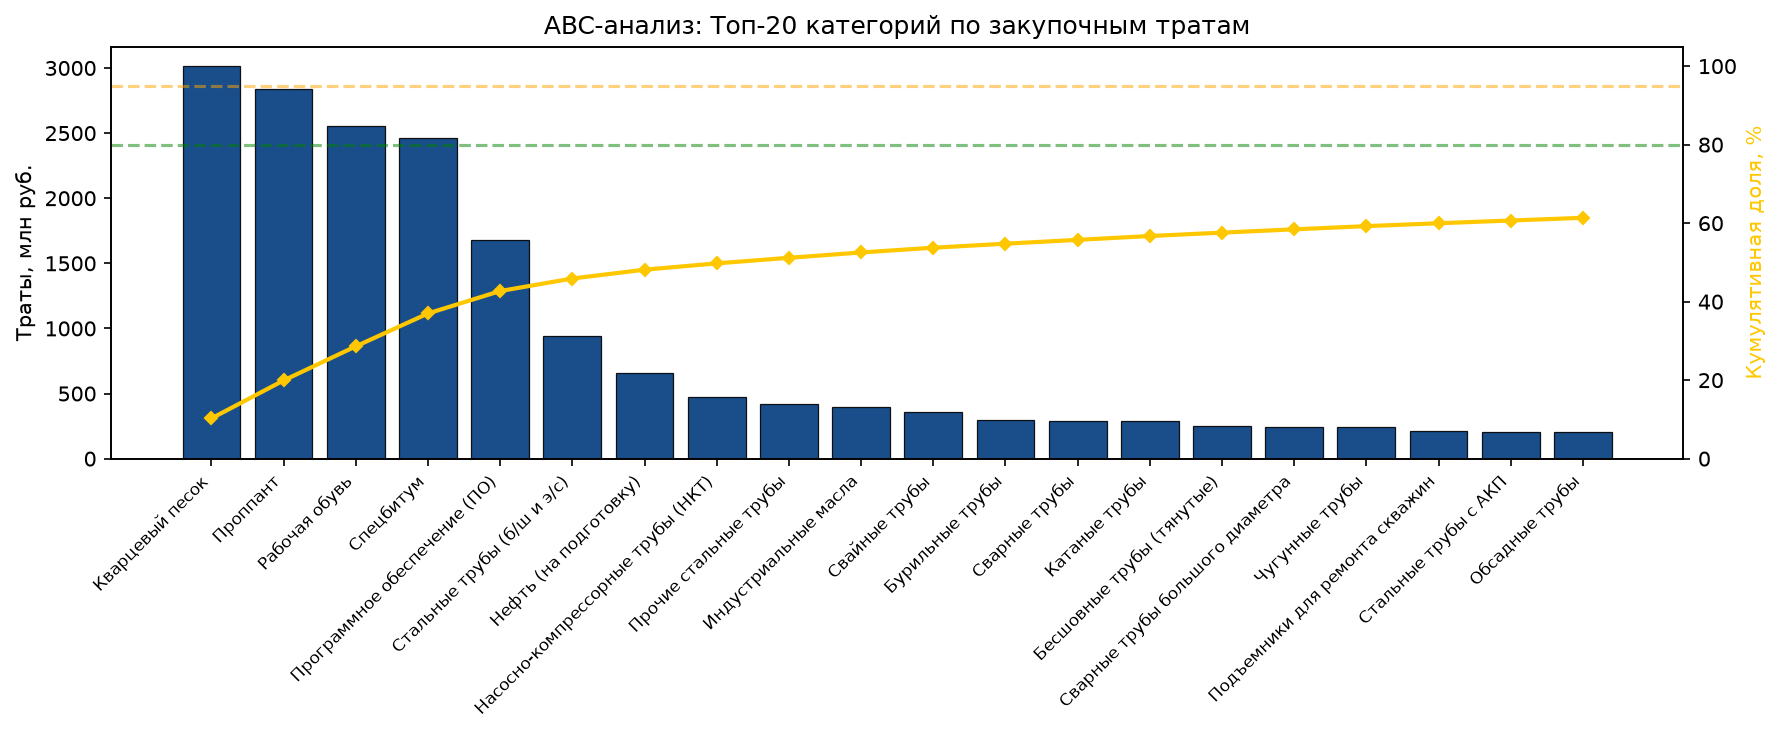

In [34]:
display(Image(filename="../images/Figure_6.png"))


## Показатель 7. Концентрация закупок по поставщикам

Всего поставщиков: 330
На крупнейшего поставщика приходится: 8.8% всех трат
На топ-5 поставщиков приходится:      27.3% всех трат
На топ-10 поставщиков приходится:     32.7% всех трат
Вывод: умеренная зависимость от крупных поставщиков — стоит держать на контроле.



,НазваниеПоставщика,СтранаРегистрации,Траты_млн,ДоляРынка_pct
0,ООО Специализированное тампонажное управление,Россия,2601.08,8.85
1,ООО СТРОИТЕЛЬНАЯ КОМПАНИЯ БАСТИОН,Россия,2473.33,8.42
2,ООО Поставщик-РФ-223,Россия,1831.25,6.23
3,ООО СМАРТСЕРВ,Россия,621.10,2.11
4,ООО Научно-производственное предприятие БУРЕНИЕ,Россия,505.67,1.72
5,ООО СТРОИТЕЛЬНАЯ КОМПАНИЯ КОНСОЛЬ,Россия,384.92,1.31
6,ООО РЕВЮР,Россия,335.93,1.14
7,ООО Поставщик-РФ-250,Россия,333.35,1.13
8,ООО Поставщик-РФ-228,Россия,271.70,0.92
9,АО Авиакомпания ИрАэро,Россия,253.63,0.86


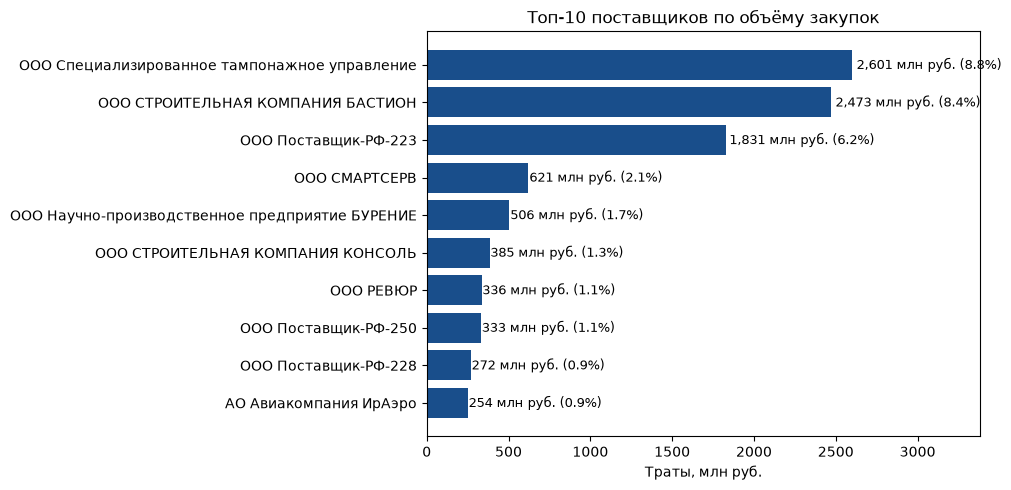

In [ ]:
query = """
SELECT 
    s.НазваниеПоставщика
    ,s.СтранаРегистрации
    ,ROUND(SUM(p.СуммаФакт) / 1e6, 2) AS Траты_млн
    ,ROUND(100.0 * SUM(p.СуммаФакт) / (SELECT SUM(СуммаФакт) FROM fact_purchases), 2) AS ДоляРынка_pct
FROM fact_purchases p
JOIN dim_suppliers s ON s.ИНН = p.ИНН
GROUP BY s.ИНН, s.НазваниеПоставщика, s.СтранаРегистрации
ORDER BY Траты_млн DESC
"""

suppliers_share = pd.read_sql(query, conn)

share_top1 = suppliers_share["ДоляРынка_pct"].iloc[0]
share_top5 = suppliers_share["ДоляРынка_pct"].head(5).sum()
share_top10 = suppliers_share["ДоляРынка_pct"].head(10).sum()

print(f"Всего поставщиков: {len(suppliers_share)}")
print(f"На крупнейшего поставщика приходится: {share_top1:.1f}% всех трат")
print(f"На топ-5 поставщиков приходится:      {share_top5:.1f}% всех трат")
print(f"На топ-10 поставщиков приходится:     {share_top10:.1f}% всех трат")
if share_top10 > 50:
    print(
        "Вывод: закупки сильно зависят от десятки крупнейших поставщиков — нужна диверсификация."
    )
elif share_top10 > 25:
    print(
        "Вывод: умеренная зависимость от крупных поставщиков — стоит держать на контроле."
    )
else:
    print(
        "Вывод: траты равномерно распределены между многими поставщиками — риск зависимости низкий."
    )
print()

# Топ-10 поставщиков:
top10 = suppliers_share.head(10).iloc[::-1]  # разворачиваем, чтобы №1 был сверху
display(top10.iloc[::-1])

plt.figure(figsize=(10, 5))
plt.barh(top10["НазваниеПоставщика"], top10["Траты_млн"], color=PALETTE[0], alpha=0.9)
for yv, (_, row) in enumerate(top10.iterrows()):
    plt.text(
        row["Траты_млн"] * 1.01,
        yv,
        f"{row['Траты_млн']:,.0f} млн руб. ({row['ДоляРынка_pct']:.1f}%)",
        va="center",
        fontsize=9,
    )
plt.xlim(0, top10["Траты_млн"].max() * 1.3)
plt.xlabel("Траты, млн руб.")
plt.title("Топ-10 поставщиков по объёму закупок", fontsize=12)
plt.tight_layout()
plt.savefig("../images/Figure_8.png", dpi=150, bbox_inches="tight")
plt.show()


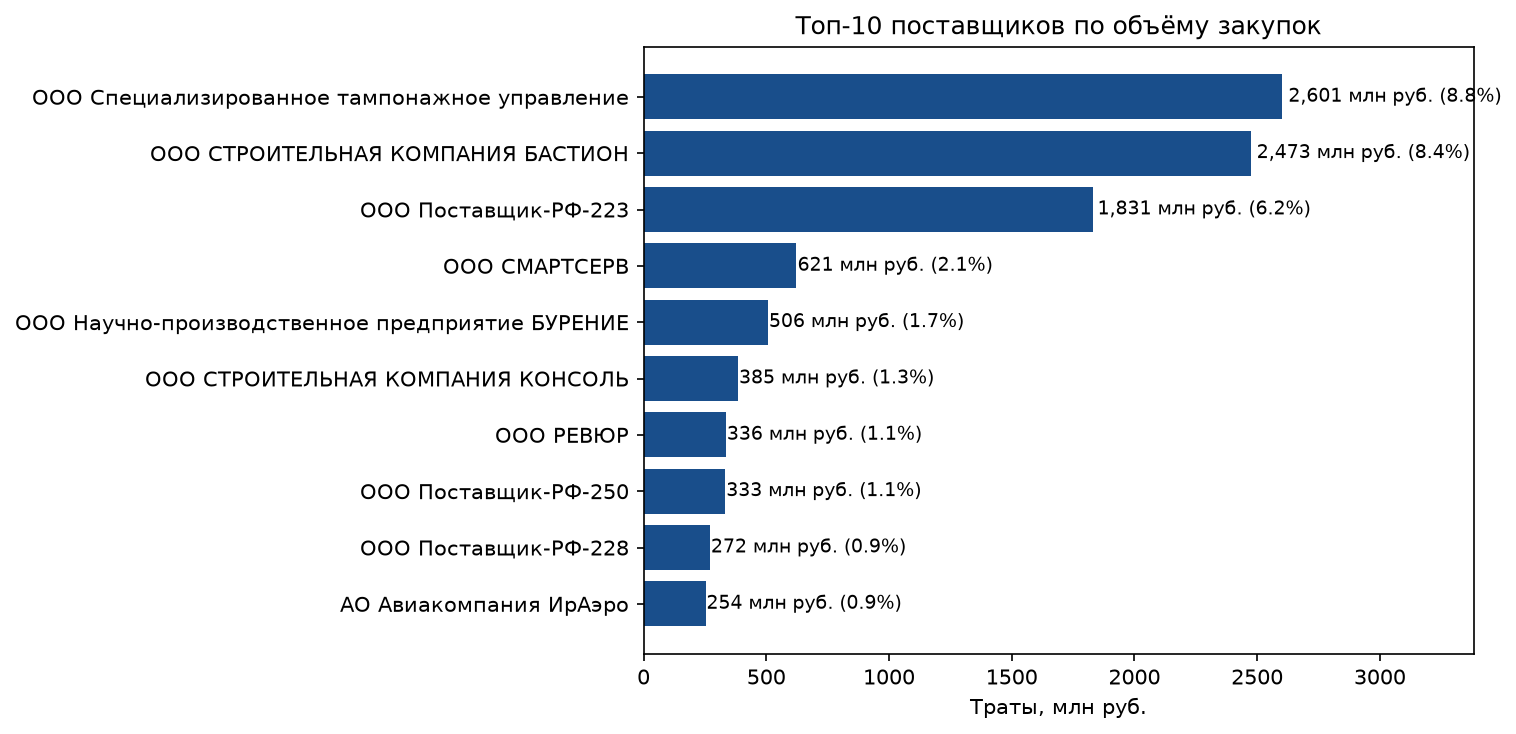

In [37]:
display(Image(filename="../images/Figure_8.png"))


## Показатель 8. Sankey-диаграмма: потоки «Бизнес-блок → Категория МТР → Страна происхождения»

**Бизнес-смысл:** Sankey наглядно показывает, через какие категории МТР и из каких стран поступают ресурсы в каждый бизнес-блок.

In [39]:
query_sankey = """
SELECT 
    f.БизнесБлок
    ,m.Категория
    ,p.СтранаПроисхождения
    ,SUM(p.СуммаФакт) AS Сумма
FROM fact_purchases p
JOIN dim_filials f ON f.КодФилиала = p.КодФилиала
JOIN dim_categories m ON m.КодГруппы = p.КодГруппы
GROUP BY f.БизнесБлок, m.Категория, p.СтранаПроисхождения
"""

sankey_data = pd.read_sql(query_sankey, conn)
sankey_data


,БизнесБлок,Категория,СтранаПроисхождения,Сумма
0,ББ Газ,ИТ и телеком,Белоруссия,2575648.02
1,ББ Газ,ИТ и телеком,Германия,945941.60
2,ББ Газ,ИТ и телеком,Казахстан,66960.72
3,ББ Газ,ИТ и телеком,Россия,1876123.51
4,ББ Газ,ИТ и телеком,США,151981.70
...,...,...,...,...
499,ББ Сервис,Хозяйственные товары и материалы,Казахстан,636860.41
500,ББ Сервис,Хозяйственные товары и материалы,Китай,2232758.17
501,ББ Сервис,Хозяйственные товары и материалы,Нидерланды,174705.47
502,ББ Сервис,Хозяйственные товары и материалы,Россия,67126107.49


In [46]:
blocks = sankey_data["БизнесБлок"].unique().tolist()
cats = sankey_data["Категория"].unique().tolist()
countries = sankey_data["СтранаПроисхождения"].unique().tolist()

nodes = blocks + cats + countries
node_index = {n: i for i, n in enumerate(nodes)}

sources = []
targets = []
values = []

for _, row in (
    sankey_data.groupby(["БизнесБлок", "Категория"])["Сумма"]
    .sum()
    .reset_index()
    .iterrows()
):
    sources.append(node_index[row["БизнесБлок"]])
    targets.append(node_index[row["Категория"]])
    values.append(round(row["Сумма"] / 1e6, 2))

for _, row in (
    sankey_data.groupby(["Категория", "СтранаПроисхождения"])["Сумма"]
    .sum()
    .reset_index()
    .iterrows()
):
    sources.append(node_index[row["Категория"]])
    targets.append(node_index[row["СтранаПроисхождения"]])
    values.append(round(row["Сумма"] / 1e6, 2))

block_colors = [PALETTE[i % len(PALETTE)] for i in range(len(blocks))]
cat_colors = ["#6D6E71"] * len(cats)
country_colors = ["#BFBFBF"] * len(countries)
node_colors = block_colors + cat_colors + country_colors

fig = go.Figure(
    data=[
        go.Sankey(
            node=dict(
                pad=15,
                thickness=20,
                line=dict(color="black", width=0.5),
                label=nodes,
                color=node_colors,
            ),
            link=dict(source=sources, target=targets, value=values),
        )
    ]
)

fig.update_layout(
    title_text="Потоки закупок: Бизнес-блок → Категория МТР → Страна происхождения",
    font_size=10,
    height=600,
)
# fig.write_image("../images/Figure_9.png", width=1200, height=700, scale=2)
fig.show()

In [ ]:
display(Image(filename="../images/Figure_9.png"))

## 9. Бизнес-выводы и рекомендации

Итоговый блок формирует ключевые сообщения для заказчика (руководства, закупочной дирекции, комитета по управлению цепочками поставок). Цифры подтягиваются напрямую из рассчитанных показателей.

In [ ]:
# Агрегаты для выводов
total_spend = fact_purchases["СуммаФакт"].sum() / 1e6
import_share = fact_purchases["ФлагИмпорта"].mean() * 100
max_import_bb = import_by_block.loc[
    import_by_block["ДоляИмпорта_pct"].idxmax(), "БизнесБлок"
]
max_import_val = import_by_block["ДоляИмпорта_pct"].max()
plan_fact_dev = plan_fact_by_block["Отклонение_pct"].abs().mean()

import_by_block_sorted = import_by_block.sort_values("ДоляИмпорта_pct", ascending=False)

# Доля импорта в услугах
svc_import_share = fact_services["ФлагИмпорта"].mean() * 100

# Серые цепочки
gray_sum = fact_purchases.merge(dim_suppliers[["ИНН", "СтранаРегистрации"]], on="ИНН")
gray_sum = (
    gray_sum[
        (gray_sum["ФлагИмпорта"] == 1) & (gray_sum["СтранаРегистрации"] == "Россия")
    ]["СуммаФакт"].sum()
    / 1e6
)

# Концентрация по поставщикам
share_top10 = suppliers_share["ДоляРынка_pct"].head(10).sum()

print("─" * 60)
print("КЛЮЧЕВЫЕ ВЫВОДЫ ПО ЗАКУПОЧНОЙ ДЕЯТЕЛЬНОСТИ")
print("─" * 60)
print(f"1. Общий объем закупок МТР за период: {total_spend:,.0f} млн руб.")
print(
    f"2. Средняя доля импорта по МТР: {import_share:.1f}% — "
    f"{'высокий' if import_share > 30 else 'умеренный' if import_share > 15 else 'низкий'} уровень импортозависимости"
)
print(f"3. Наибольшая импортозависимость в блоке '{max_import_bb}' ({max_import_val:.1f}%)")
print("   Все бизнес-блоки МТР укладываются в целевой порог ≤15%.")
print(
    f"4. Среднее отклонение план/факт: {plan_fact_dev:.1f}% — "
    f"{'требует корректировки методики планирования' if plan_fact_dev > 10 else 'в пределах нормы'}"
)
print(
    f"5. Объем 'серых' импортных цепочек (РФ-поставщик + импорт): {gray_sum:,.0f} млн руб."
)
print(
    f"6. На топ-10 поставщиков приходится {share_top10:.1f}% всех трат — "
    f"{'высокая зависимость от крупнейших поставщиков, требуется диверсификация' if share_top10 > 50 else ('умеренная концентрация' if share_top10 > 25 else 'конкурентный рынок, риск зависимости низкий')}"
)
print(
    f"7. Доля импорта в закупках услуг: {svc_import_share:.1f}% — "
    f"{'выше целевого коридора' if svc_import_share > 5 else 'в целевом коридоре 1–4%'}"
)
print()
print("СТРУКТУРИРОВАННЫЕ РЕКОМЕНДАЦИИ:")
print("• Зафиксировать достигнутый уровень импортозависимости по МТР (≤15% на блок) в KPI закупочных дирекций.")
print("• Приоритизировать локализацию для категорий класса A (≈80% трат) и категорий в правом верхнем квадранте матрицы Кральича.")
print(
    f"• Для блока '{max_import_bb}' — единственного, близкого к порогу 15%, — подготовить план снижения импорта с горизонтом 1–2 года."
)
print("• Продолжать держать долю импорта в услугах в коридоре 1–4%; отдельно контролировать полугодия с резкими всплесками.")
print("• Провести аудит поставщиков, через которых оформляются 'серые' импортные цепочки, и перейти к прямым контрактам с производителями где возможно.")
print("• Ужесточить требования к раскрытию страны регистрации и бенефициаров в конкурсной документации.")
print("• Диверсифицировать поставщиков в категориях с высокой критичностью замещения (матрица Кральича).")
print("─" * 60)



────────────────────────────────────────────────────────────
КЛЮЧЕВЫЕ ВЫВОДЫ ПО ЗАКУПОЧНОЙ ДЕЯТЕЛЬНОСТИ
────────────────────────────────────────────────────────────
1. Общий объем закупок МТР за период: 29,381 млн руб.
2. Средняя доля импорта по МТР: 41.7% — высокий уровень импортозависимости
3. Наибольшая импортозависимость в блоке 'ББ Газ' (13.5%)
   Все бизнес-блоки МТР укладываются в целевой порог ≤15%.
4. Среднее отклонение план/факт: 2.8% — в пределах нормы
5. Объем 'серых' импортных цепочек (РФ-поставщик + импорт): 1,743 млн руб.
6. На топ-10 поставщиков приходится 32.7% всех трат — умеренная концентрация
7. Доля импорта в закупках услуг: 38.4% — выше целевого коридора

СТРУКТУРИРОВАННЫЕ РЕКОМЕНДАЦИИ:
• Зафиксировать достигнутый уровень импортозависимости по МТР (≤15% на блок) в KPI закупочных дирекций.
• Приоритизировать локализацию для категорий класса A (≈80% трат) и категорий в правом верхнем квадранте матрицы Кральича.
• Для блока 'ББ Газ' — единственного, близкого к порогу

## Схема данных
 
Ниже представлена логическая схема хранилища: справочники (Dim) и таблицы фактов (Fact), а также расчётные витрины.

```mermaid
%%{init: {'theme': 'base', 'themeVariables': { 'primaryColor': '#E6F0FA', 'edgeLabelBackground':'#FFFFFF'}}}%%
erDiagram
    DIM_FILIALS ||--o{ FACT_PURCHASES : "КодФилиала"
    DIM_FILIALS ||--o{ FACT_SERVICES : "КодФилиала"
    DIM_CATEGORIES ||--o{ FACT_PURCHASES : "КодГруппы"
    DIM_CATEGORIES ||--o{ FACT_SERVICES : "КодГруппы"
    DIM_SUPPLIERS ||--o{ FACT_PURCHASES : "ИНН"
    DIM_SUPPLIERS ||--o{ FACT_SERVICES : "ИНН"
    DIM_COMMISSIONS ||--o{ FACT_PURCHASES : "КодКомиссии"
    DIM_COMMISSIONS ||--o{ FACT_SERVICES : "КодКомиссии"

    DIM_FILIALS {
        int КодФилиала PK
        string НазваниеФилиала
        string БизнесБлок
        string Регион
        string ИНН
    }

    DIM_CATEGORIES {
        int КодГруппы PK
        string НазваниеГруппы
        string Категория
    }

    DIM_SUPPLIERS {
        int ИНН PK
        string НазваниеПоставщика
        string УровеньПоставщика
        string СтатусПоставщика
        string СтранаРегистрации
        string СтранаБенефициаров
        date ДатаРегистрации
        float БазовыйРейтингНадежности
    }

    DIM_COMMISSIONS {
        string КодКомиссии PK
        string НазваниеКомиссии
        string ТипЗакупки
        string ТипКомиссии
        date ДатаЗакупочнойКомиссии
    }

    FACT_PURCHASES {
        int КодЗакупки
        string НазваниеЗакупки
        date ДатаЗакупки
        int КодФилиала FK
        int ИНН FK
        int КодГруппы FK
        string КодКомиссии FK
        float СуммаПлан
        float СуммаФакт
        string СтранаПроисхождения
        int ФлагИмпорта
        string СтатусКонтракта
    }

    FACT_SERVICES {
        int КодЗакупки
        string НазваниеЗакупки
        date ДатаЗакупки
        int КодФилиала FK
        int ИНН FK
        int КодГруппы FK
        string КодКомиссии FK
        float СуммаПлан
        float СуммаФакт
        int ФлагИмпорта
        string СтатусКонтракта
    }
```

**Описание связей:**
- `fact_purchases` и `fact_services` связаны с `dim_filials` по `КодФилиала`.
- Обе факт-таблицы связаны с `dim_categories` по `КодГруппы` (ранее `dim_categories`).
- Обе факт-таблицы связаны с `dim_suppliers` по `ИНН`.
- Обе факт-таблицы связаны с `dim_commissions` по `КодКомиссии`.
- Расчётные витрины в `data/_processed/` строятся поверх фактов и справочников.
